# Limpieza de artefactos oculares con ICA
## Notebook 01b — entre el acondicionamiento (01) y la transformación TF (02)

Este notebook toma la señal ya acondicionada (`eeg_eye_state_clean.csv`: winsorizada,
filtrada en banda y normalizada Z) y le remueve los **componentes oculares y musculares**
mediante **Análisis de Componentes Independientes (ICA)**.

---

## Por qué este paso, y qué esperar

El label del dataset **es el estado de los ojos** (abiertos = 0 / cerrados = 1). Los
artefactos oculares están físicamente ligados a ese label:

- **Ojos abiertos** → parpadeos, sacadas y tensión muscular → artefactos grandes en
  canales frontales (AF3, AF4, F7, F8) y temporales (T7, T8).
- **Ojos cerrados** → sin parpadeos, pero aparece el ritmo alfa (efecto Berger) en
  occipitales (O1, O2, P7, P8).

En la clasificación previa (notebooks 06/07) los canales frontales y temporales dominaban
la importancia del Random Forest: el clasificador estaba usando los **artefactos** como
atajo, no el ritmo alfa fisiológico.

> **Expectativa honesta:** remover los artefactos probablemente **no suba** la accuracy —
> puede bajarla, porque le quitamos al modelo información correlacionada con el label.
> El valor del paso es interpretativo: la accuracy que quede *después* de limpiar es
> atribuible al ritmo alfa neural real. Si tras limpiar suben los canales occipitales y
> la accuracy se sostiene → resultado fuerte. Si colapsa a azar → demuestra que el modelo
> dependía de artefactos. En ambos casos respondemos la pregunta central del proyecto.

## Restricción metodológica: sin canal EOG dedicado

El Emotiv EPOC tiene **14 canales y ningún electrodo EOG**. Por eso los componentes
oculares se identifican por heurística, combinando tres criterios por componente:

1. **Razón frontal** — fracción del peso espacial del componente que cae en los canales
   cercanos a los ojos (AF3, AF4, F7, F8). Un componente ocular proyecta fuerte ahí.
2. **Correlación frontal** — correlación de la serie del componente con la señal media
   de esos canales frontales (que actúan como 'EOG virtual').
3. **Curtosis** — los parpadeos/sacadas son picos no-gaussianos → curtosis alta.

Se marca un componente como ocular si es frontalmente dominante **y** además correlaciona
fuerte con el frontal **o** tiene curtosis alta. El criterio es deliberadamente
**conservador**: con solo 14 canales, remover de más destruye señal cerebral útil.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import FastICA
from scipy.stats import kurtosis

FS = 128  # Hz
CHANNELS = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
FRONTAL  = ['AF3','AF4','F7','F8']   # canales proxy de EOG (cercanos a los ojos)
OCCIPITAL = ['O1','O2','P7','P8']    # canales del ritmo alfa
TARGET_COL = 'eyeDetection'

df = pd.read_csv('./data/eeg_eye_state_clean.csv')
X = df[CHANNELS].values   # (n_muestras, 14)
print(f'Señal acondicionada: {X.shape[0]} muestras x {X.shape[1]} canales')
print(f'Duración: {X.shape[0]/FS:.1f} s  |  Canales frontales (EOG virtual): {FRONTAL}')


Señal acondicionada: 14980 muestras x 14 canales
Duración: 117.0 s  |  Canales frontales (EOG virtual): ['AF3', 'AF4', 'F7', 'F8']


## Paso 1 — Descomposición ICA

`FastICA` separa los 14 canales en 14 componentes independientes. La matriz de mezcla
`mixing_` (14 canales × 14 componentes) describe cómo cada componente se proyecta sobre
los electrodos — es el equivalente a un 'mapa espacial' (sin topografía 2D porque no
tenemos el montaje de electrodos cargado).


In [2]:
ica = FastICA(n_components=14, whiten='unit-variance', max_iter=2000,
              tol=1e-4, random_state=42)
S = ica.fit_transform(X)        # (n_muestras, 14) — series de los componentes
A = ica.mixing_                 # (14 canales, 14 componentes) — mapas espaciales

print(f'Componentes independientes: {S.shape[1]}')
print(f'Matriz de mezcla (mixing_): {A.shape}  -> [canales x componentes]')
print(f'Convergió en {ica.n_iter_} iteraciones')


Componentes independientes: 14
Matriz de mezcla (mixing_): (14, 14)  -> [canales x componentes]
Convergió en 37 iteraciones


## Paso 2 — Identificar componentes oculares

Se calculan los tres criterios para cada componente y se marca como ocular según la
regla combinada. Los umbrales se exponen como variables para poder ajustarlos.


In [3]:
frontal_idx = [CHANNELS.index(c) for c in FRONTAL]
frontal_mean = X[:, frontal_idx].mean(axis=1)   # 'EOG virtual'

# Umbrales (conservadores)
TH_FRONTAL_RATIO = 0.50   # >50% del peso espacial en canales frontales
TH_CORR          = 0.50   # |corr| con el EOG virtual
TH_KURTOSIS      = 5.0    # picos no-gaussianos (parpadeos/sacadas)

metrics = []
for i in range(S.shape[1]):
    mapa = np.abs(A[:, i])
    frontal_ratio = mapa[frontal_idx].sum() / mapa.sum()
    corr_frontal  = abs(np.corrcoef(S[:, i], frontal_mean)[0, 1])
    kurt          = kurtosis(S[:, i])
    es_ocular = (frontal_ratio > TH_FRONTAL_RATIO) and \
                (corr_frontal > TH_CORR or kurt > TH_KURTOSIS)
    metrics.append({'Componente': i, 'Razón frontal': round(frontal_ratio, 3),
                    'Corr frontal': round(corr_frontal, 3), 'Curtosis': round(kurt, 2),
                    'Ocular': es_ocular})

metrics_df = pd.DataFrame(metrics).sort_values('Razón frontal', ascending=False)
print(metrics_df.to_string(index=False))

# Permite forzar manualmente la lista (None = automático)
MANUAL_OCULAR = None
ocular_components = (MANUAL_OCULAR if MANUAL_OCULAR is not None
                    else metrics_df[metrics_df['Ocular']]['Componente'].tolist())
print(f'\nComponentes marcados como oculares: {ocular_components}')
print(f'Se removerán {len(ocular_components)} de {S.shape[1]} componentes.')


 Componente  Razón frontal  Corr frontal  Curtosis  Ocular
         10          0.508         0.828     11.57    True
          4          0.432         0.363      8.52   False
         12          0.425         0.076    320.50   False
          5          0.293         0.075     15.90   False
          8          0.264         0.031      6.06   False
         11          0.227         0.165      0.29   False
          2          0.178         0.055     25.90   False
          1          0.167         0.335      8.01   False
          7          0.126         0.105     34.53   False
          0          0.121         0.100      0.66   False
          9          0.112         0.066      3.33   False
         13          0.107         0.031     28.41   False
          3          0.077         0.018    105.60   False
          6          0.071         0.036     -0.55   False

Componentes marcados como oculares: [10]
Se removerán 1 de 14 componentes.


## Paso 3 — Mapas espaciales de los componentes

Peso de cada componente sobre los 14 canales. Un componente ocular concentra su peso
en los frontales (rojo); uno cerebral lo reparte o se concentra en occipitales.


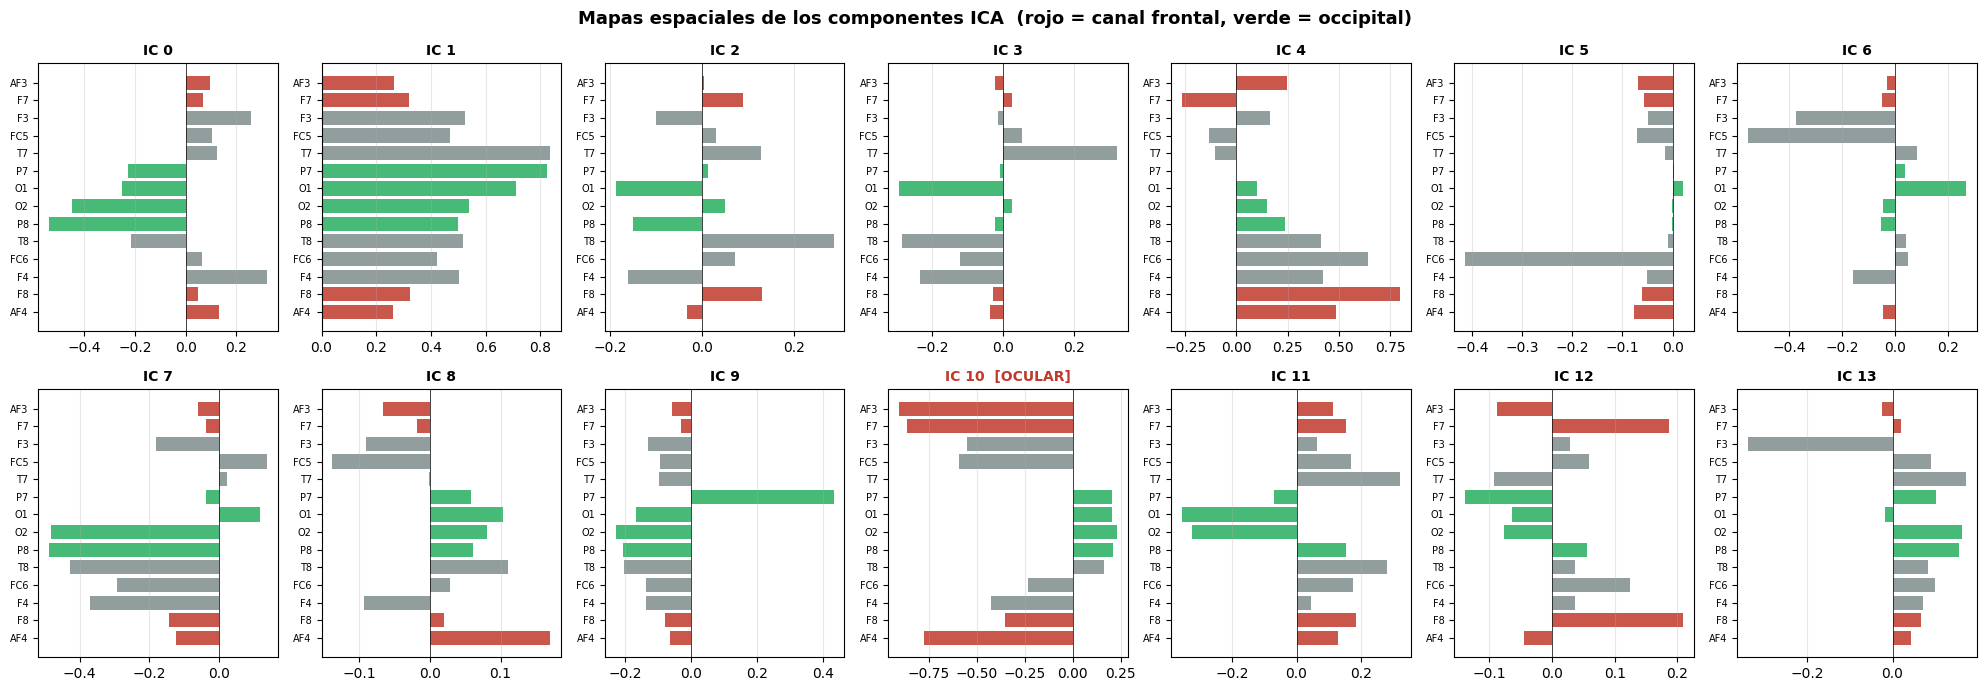

In [4]:
n_show = S.shape[1]
fig, axes = plt.subplots(2, 7, figsize=(20, 7))
fig.suptitle('Mapas espaciales de los componentes ICA  (rojo = canal frontal, verde = occipital)',
             fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i >= n_show:
        ax.axis('off'); continue
    pesos = A[:, i]
    colores = ['#c0392b' if c in FRONTAL else '#27ae60' if c in OCCIPITAL else '#7f8c8d'
               for c in CHANNELS]
    ax.barh(range(len(CHANNELS)), pesos, color=colores, alpha=0.85)
    ax.set_yticks(range(len(CHANNELS)))
    ax.set_yticklabels(CHANNELS, fontsize=7)
    ax.invert_yaxis()
    es_ocular = i in ocular_components
    ax.set_title(f'IC {i}' + ('  [OCULAR]' if es_ocular else ''),
                 fontsize=10, fontweight='bold',
                 color='#c0392b' if es_ocular else 'black')
    ax.axvline(0, color='k', lw=0.5)
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()


## Paso 4 — Series temporales de los componentes oculares

Los componentes oculares muestran picos altos y aislados (parpadeos/sacadas).
Se muestran los primeros 30 s.


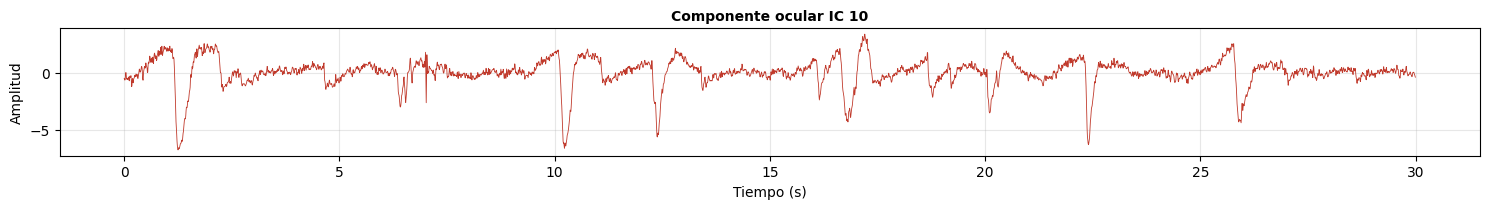

In [5]:
t = np.arange(X.shape[0]) / FS
win = t < 30   # primeros 30 segundos

if len(ocular_components) > 0:
    fig, axes = plt.subplots(len(ocular_components), 1,
                             figsize=(15, 2.2 * len(ocular_components)), squeeze=False)
    for ax, ic in zip(axes[:, 0], ocular_components):
        ax.plot(t[win], S[win, ic], lw=0.6, color='#c0392b')
        ax.set_title(f'Componente ocular IC {ic}', fontsize=10, fontweight='bold')
        ax.set_ylabel('Amplitud')
        ax.grid(alpha=0.3)
    axes[-1, 0].set_xlabel('Tiempo (s)')
    plt.tight_layout(); plt.show()
else:
    print('No se marcó ningún componente como ocular con los umbrales actuales.')


## Paso 5 — Reconstrucción de la señal limpia

Se ponen en cero los componentes oculares y se reconstruye la señal en el espacio de
canales. Comparación antes/después en un canal frontal (donde debería cambiar mucho) y
uno occipital (donde el alfa debería preservarse).


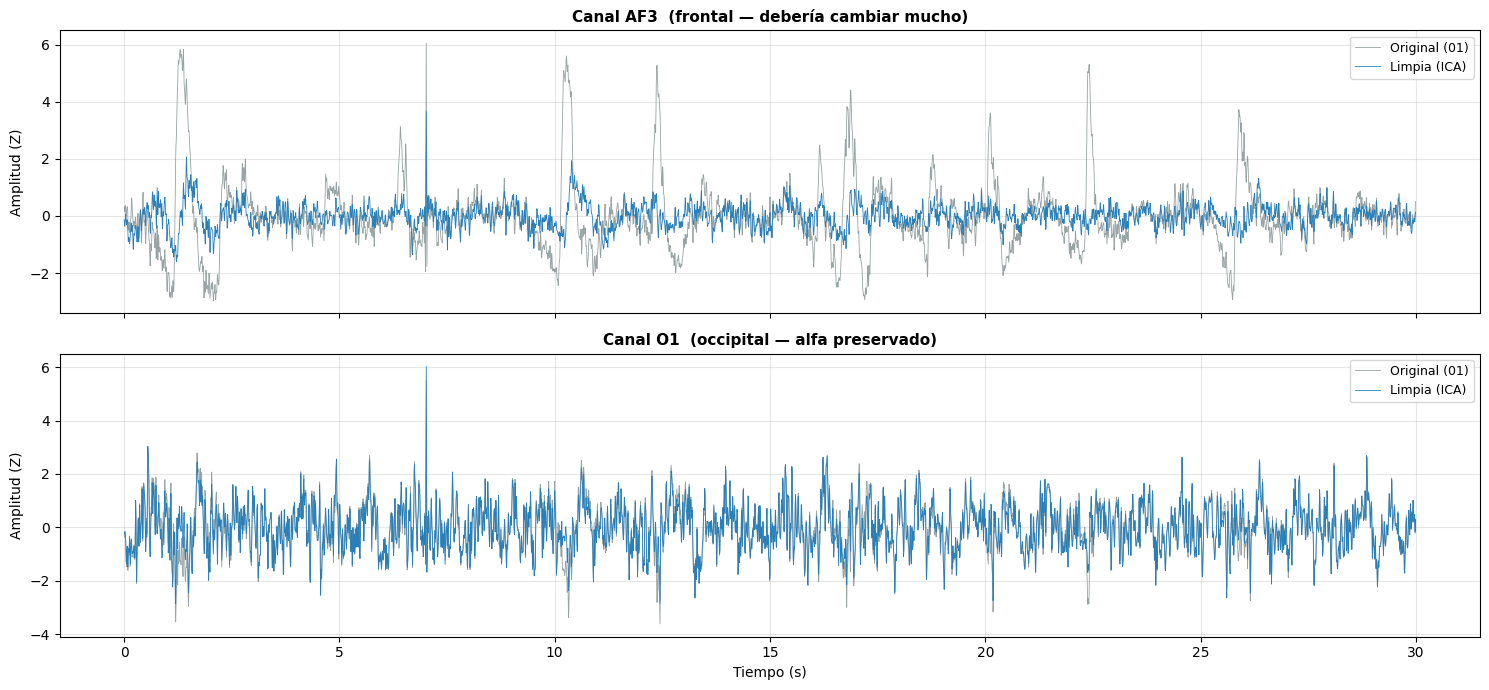

In [6]:
S_clean = S.copy()
S_clean[:, ocular_components] = 0
X_clean = ica.inverse_transform(S_clean)   # de vuelta al espacio de canales

fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)
for ax, ch in zip(axes, ['AF3', 'O1']):
    j = CHANNELS.index(ch)
    ax.plot(t[win], X[win, j],       lw=0.6, color='#7f8c8d', label='Original (01)', alpha=0.8)
    ax.plot(t[win], X_clean[win, j], lw=0.6, color='#2980b9', label='Limpia (ICA)')
    tipo = 'frontal — debería cambiar mucho' if ch in FRONTAL else 'occipital — alfa preservado'
    ax.set_title(f'Canal {ch}  ({tipo})', fontsize=11, fontweight='bold')
    ax.set_ylabel('Amplitud (Z)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel('Tiempo (s)')
plt.tight_layout(); plt.show()


## Paso 6 — Cuánto cambió cada canal

Varianza removida por canal = `1 - var(limpia)/var(original)`. Si la limpieza fue
correcta, los canales frontales pierden mucha varianza y los occipitales casi nada.


Canal  Varianza removida (%)     Grupo
  AF3                   81.9   Frontal
   F7                   74.5   Frontal
   F3                   30.1      Otro
  FC5                   34.9      Otro
   T7                    0.0      Otro
   P7                    4.2 Occipital
   O1                    4.1 Occipital
   O2                    5.2 Occipital
   P8                    4.3 Occipital
   T8                    2.6      Otro
  FC6                    5.3      Otro
   F4                   18.1      Otro
   F8                   12.6   Frontal
  AF4                   59.6   Frontal

Media frontal:   57.2%
Media occipital: 4.4%


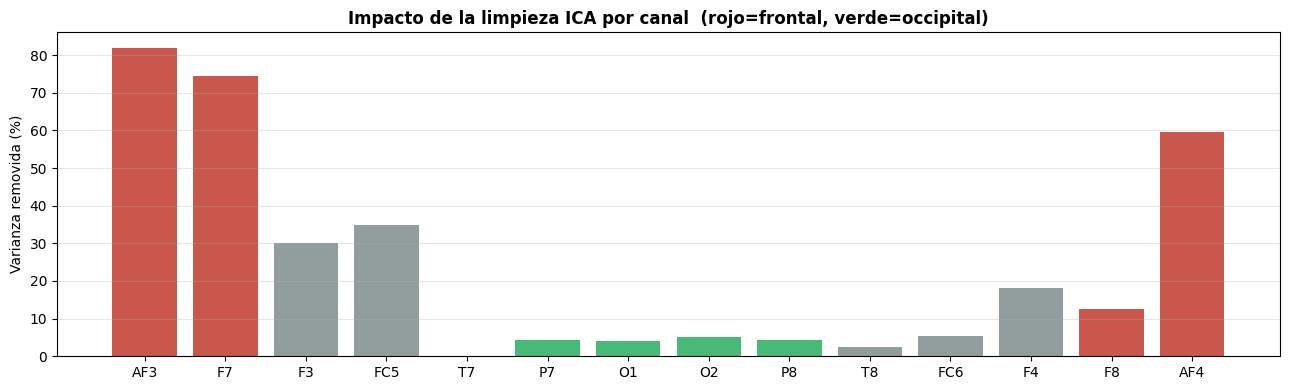

In [7]:
var_orig  = X.var(axis=0)
var_clean = X_clean.var(axis=0)
var_removed = 1 - var_clean / var_orig

resumen = pd.DataFrame({'Canal': CHANNELS,
                        'Varianza removida (%)': (var_removed * 100).round(1)})
resumen['Grupo'] = ['Frontal' if c in FRONTAL else 'Occipital' if c in OCCIPITAL
                    else 'Otro' for c in CHANNELS]
print(resumen.to_string(index=False))
print(f"\nMedia frontal:   {var_removed[[CHANNELS.index(c) for c in FRONTAL]].mean()*100:.1f}%")
print(f"Media occipital: {var_removed[[CHANNELS.index(c) for c in OCCIPITAL]].mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(13, 4))
colores = ['#c0392b' if c in FRONTAL else '#27ae60' if c in OCCIPITAL else '#7f8c8d'
           for c in CHANNELS]
ax.bar(CHANNELS, var_removed * 100, color=colores, alpha=0.85)
ax.set_ylabel('Varianza removida (%)')
ax.set_title('Impacto de la limpieza ICA por canal  (rojo=frontal, verde=occipital)',
             fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## Limitación — el artefacto temporal/muscular de T7 no es removible con ICA

El componente ocular (IC frontal) se aisló de forma limpia: es una fuente **dipolar**
única. El artefacto **muscular (EMG)** es distinto — son muchas unidades motoras
espacialmente distribuidas que, con solo **14 canales**, la ICA no logra separar en un
componente propio. Esta es una limitación conocida de la ICA con pocos electrodos.

El diagnóstico siguiente lo confirma para este registro:

1. **No hay componente muscular aislable.** Se buscó un componente que fuera
   temporal-dominante (T7/T8) **y** con espectro dominado por alta frecuencia (>20 Hz,
   la firma del EMG). Ningún componente cumple ambas: el más temporal (dominante en T7,
   curtosis alta) tiene solo ~36% de su potencia sobre 20 Hz → es un **transitorio**
   (picos esporádicos / movimiento), no EMG sostenido.

2. **Removerlo sería contraproducente.** Ese componente T7-dominante mezcla el artefacto
   de T7 con alfa de O1. Eliminarlo quita solo ~10% de la varianza de T7 pero ~13% del
   **alfa genuino de O1** — se daña un canal alfa real para apenas tocar el artefacto.

**Decisión:** se conserva únicamente la remoción del componente ocular. El residual de
T7 (visible como la dominancia de T7 en la importancia del Random Forest de los
notebooks 06/07) se documenta como **limitación metodológica** atribuible al bajo número
de canales del Emotiv EPOC.


In [8]:
## Diagnóstico: ¿existe un componente muscular en T7?
from scipy.signal import welch

tidx = [CHANNELS.index(c) for c in ['T7', 'T8']]
diag = []
for i in range(S.shape[1]):
    m = np.abs(A[:, i])
    f, P = welch(S[:, i], fs=FS, nperseg=256)
    band = (f >= 4) & (f < 40); hi = (f >= 20) & (f < 40)
    diag.append({'IC': i, 'Canal dom': CHANNELS[np.argmax(m)],
                 'Razón temporal': round(m[tidx].sum()/m.sum(), 2),
                 'Potencia >20Hz': round(P[hi].sum()/P[band].sum(), 2),
                 'Curtosis': round(float(kurtosis(S[:, i])), 1)})
diag_df = pd.DataFrame(diag).sort_values('Razón temporal', ascending=False)
print('Criterio muscular = temporal-dominante Y potencia >20Hz alta (ninguno cumple):')
print(diag_df.head(6).to_string(index=False))

# Impacto de remover el componente más T7-dominante (además del ocular)
ic_t7 = int(diag_df.iloc[0]['IC'])
S_test = S.copy(); S_test[:, ocular_components + [ic_t7]] = 0
X_test = ica.inverse_transform(S_test)
vr = 1 - X_test.var(0) / X.var(0)
print(f'\nRemover IC ocular + IC {ic_t7} (T7-dominante):')
print(f"  T7: {vr[CHANNELS.index('T7')]*100:.1f}% removido  |  "
      f"O1: {vr[CHANNELS.index('O1')]*100:.1f}% removido (alfa dañado)")
print('  -> mal negocio: se conserva solo la remoción ocular.')


Criterio muscular = temporal-dominante Y potencia >20Hz alta (ninguno cumple):
 IC Canal dom  Razón temporal  Potencia >20Hz  Curtosis
  3        T7            0.40            0.36     105.6
  2        T8            0.29            0.46      25.9
 11        O1            0.24            0.34       0.3
  1        T7            0.19            0.25       8.0
 13        F3            0.18            0.37      28.4
  7        P8            0.15            0.33      34.5

Remover IC ocular + IC 3 (T7-dominante):
  T7: 10.2% removido  |  O1: 12.8% removido (alfa dañado)
  -> mal negocio: se conserva solo la remoción ocular.


## Paso 7 — Guardado

Se guarda la señal limpia con las mismas columnas que `eeg_eye_state_clean.csv` para que
el notebook 02 pueda consumirla. Se preserva el dataset original sin limpiar para poder
comparar 'con vs sin limpieza' en la clasificación.


In [9]:
df_ica = df.copy()
df_ica[CHANNELS] = X_clean
out_path = './data/eeg_eye_state_clean_ica.csv'
df_ica.to_csv(out_path, index=False)
print(f'Guardado: {out_path}')
print(f'  Shape: {df_ica.shape}')
print(f'  Componentes oculares removidos: {ocular_components}')
print(f'  Columnas: {list(df_ica.columns)}')


Guardado: ./data/eeg_eye_state_clean_ica.csv
  Shape: (14980, 16)
  Componentes oculares removidos: [10]
  Columnas: ['AF3', 'F7', 'F3', 'FC5', 'T7', 'P7', 'O1', 'O2', 'P8', 'T8', 'FC6', 'F4', 'F8', 'AF4', 'eyeDetection', 'time_sec']
